<a href="https://colab.research.google.com/github/Zekaiiz/MSSP-6070-Zekai-Zhang/blob/main/CASE_STUDY_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
df = pd.read_csv('InternetSales.csv', encoding='latin1')
print(df.head())

Saving InternetSales.csv to InternetSales.csv
   ID  CustomerKey  GeographyKey         City CountryRegionCode  \
0   0        11000            26  Rockhampton                AU   
1   1        11000            26  Rockhampton                AU   
2   2        11000            26  Rockhampton                AU   
3   3        11000            26  Rockhampton                AU   
4   4        11000            26  Rockhampton                AU   

  EnglishCountryRegionName CustomerAlternateKey Title FirstName MiddleName  \
0                Australia           AW00011000   NaN       Jon          V   
1                Australia           AW00011000   NaN       Jon          V   
2                Australia           AW00011000   NaN       Jon          V   
3                Australia           AW00011000   NaN       Jon          V   
4                Australia           AW00011000   NaN       Jon          V   

   ... ProductStandardCost  TotalProductCost SalesAmount    TaxAmt  Freight  \
0  

/tmp/ipython-input-3042886220.py:4: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('InternetSales.csv', encoding='latin1')


Q1 – Internet Sales by Year for Each Country Region

In [17]:
sales_df = df.groupby(['EnglishCountryRegionName', 'OrderDate'])['SalesAmount'].sum().reset_index()
df["OrderDate"] = pd.to_datetime(df["OrderDate"], errors="coerce")
df["Year"] = df["OrderDate"].dt.year
sales_summary = df.groupby(['EnglishCountryRegionName', 'Year'])['SalesAmount'].sum().reset_index()
print(sales_summary)

   EnglishCountryRegionName  Year   SalesAmount
0                 Australia  2010  2.090978e+04
1                 Australia  2011  2.563732e+06
2                 Australia  2012  2.128407e+06
3                 Australia  2013  4.339443e+06
4                 Australia  2014  8.507720e+03
5                    Canada  2010  3.578270e+03
6                    Canada  2011  5.715718e+05
7                    Canada  2012  3.076045e+05
8                    Canada  2013  1.085633e+06
9                    Canada  2014  9.457620e+03
10                   France  2010  3.399990e+03
11                   France  2011  4.108453e+05
12                   France  2012  6.480655e+05
13                   France  2013  1.578512e+06
14                   France  2014  3.195060e+03
15                  Germany  2011  5.205002e+05
16                  Germany  2012  6.086580e+05
17                  Germany  2013  1.761876e+06
18                  Germany  2014  3.277830e+03
19           United Kingdom  2010  6.990

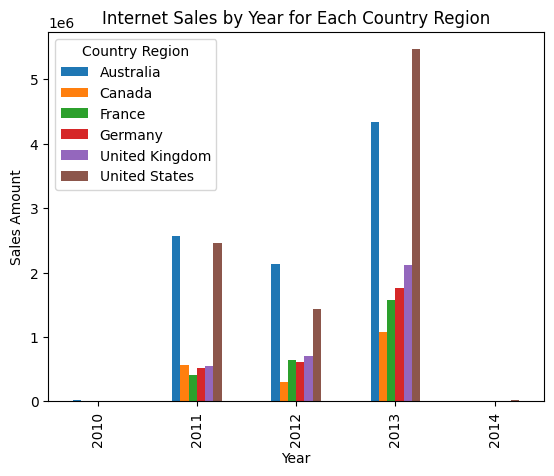

In [26]:
pivot_df.plot(kind="bar")

plt.title("Internet Sales by Year for Each Country Region")
plt.xlabel("Year")
plt.ylabel("Sales Amount")
plt.legend(title="Country Region")
plt.show()

Q2-Generate summary statistics including min, max, and standard deviation for Yearly Income, Gender by Country Regions.  

In [28]:
df_sumstats = df[["EnglishCountryRegionName", "Gender", "YearlyIncome"]].copy()
df_sumstats = df_sumstats.groupby(["EnglishCountryRegionName", "Gender"]).agg(["min", "max", "std"])
print(df_sumstats)


                                YearlyIncome                      
                                         min     max           std
EnglishCountryRegionName Gender                                   
Australia                F             10000  160000  30613.956169
                         M             10000  170000  32550.778171
Canada                   F             10000  170000  19435.158438
                         M             10000  170000  22702.851581
France                   F             10000  110000  28421.836245
                         M             10000  110000  28665.660622
Germany                  F             10000  130000  37622.814569
                         M             10000  130000  37487.619366
United Kingdom           F             10000  170000  51130.689140
                         M             10000  170000  50963.707551
United States            F             10000  170000  25498.805483
                         M             10000  170000  26520.34

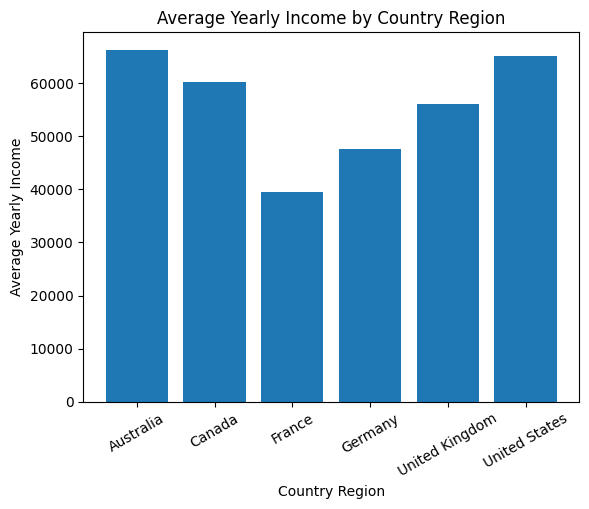

In [34]:
avg_income = df.groupby("EnglishCountryRegionName")["YearlyIncome"].mean().reset_index()

plt.bar(avg_income["EnglishCountryRegionName"], avg_income["YearlyIncome"])
plt.xlabel("Country Region")
plt.ylabel("Average Yearly Income")
plt.title("Average Yearly Income by Country Region")
plt.xticks(rotation=30)
plt.show()

Q3-What is the average price of the product category that generates the most sales?

In [10]:
def categorize_product(name):
    name = name.lower()

    # Bicycle products (complete bikes)
    if 'mountain-' in name or 'road-' in name or 'touring-' in name:
        return 'Bicycle'

    # Components and repair parts
    elif 'tire' in name or 'tube' in name or 'fender' in name or 'bottle cage' in name or 'patch' in name:
        return 'Components'

    # Safety-related products
    elif 'helmet' in name:
        return 'Safety Gear'

    # Apparel / clothing items
    elif 'jersey' in name or 'vest' in name or 'shorts' in name or 'gloves' in name or 'socks' in name:
        return 'Apparel'

    # Accessories & add-ons
    elif 'pack' in name or 'rack' in name or 'stand' in name or 'wash' in name or 'bottle' in name:
        return 'Accessories'

    # Everything else
    else:
        return 'Other'

# Apply category classification to product names
df['ProductCategory'] = df['EnglishProductName'].apply(categorize_product)


In [12]:
top_category = df.groupby("ProductCategory")["SalesAmount"].sum().idxmax()
print("Top Category:", top_category)

avg_price = df[df["ProductCategory"] == top_category]["UnitPrice"].mean()
print("Average Unit Price:", avg_price)

Top Category: Bicycle
Average Unit Price: 1862.4231930746462


Q4-Does owning a home make a difference in sales? Explain your analysis.


In [14]:
home_sales = df.groupby("HouseOwnerFlag")["SalesAmount"].mean().reset_index()
print(home_sales)

   HouseOwnerFlag  SalesAmount
0               0   479.882744
1               1   488.869033


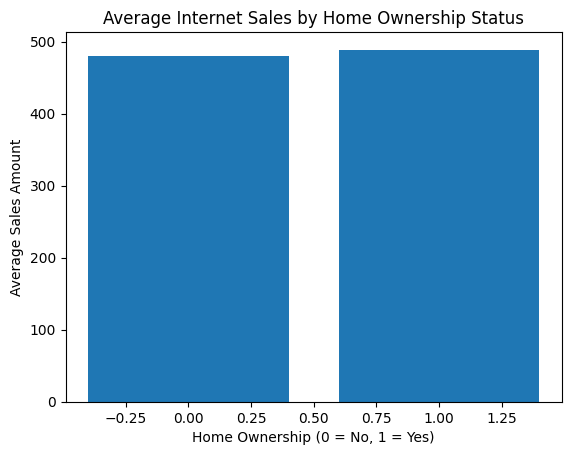

In [15]:
import matplotlib.pyplot as plt

plt.bar(home_sales["HouseOwnerFlag"], home_sales["SalesAmount"])
plt.xlabel("Home Ownership (0 = No, 1 = Yes)")
plt.ylabel("Average Sales Amount")
plt.title("Average Internet Sales by Home Ownership Status")
plt.show()